# 🌍 Global Resilience Index — 2030 Forecast
### Scenario-Based Forecasting: Base / Optimistic / Pessimistic
### Coverage: 100 In-Filter Countries + Out-of-Filter Countries
---
**Method:** OLS Linear Regression per Country × Domain series  
**Scenarios:** Base | Optimistic (+1.5 SE) | Pessimistic (−1.5 SE)  
**Validation:** Backtest on 2021–2023 holdout  
**Output:** Domain Scores, Composite Scores, Global 2030 Ranking


<div style="
background:linear-gradient(135deg,#0EA5E9,#2563EB,#4338CA);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

📥 0. Imports & Setup

</div>

<sub style="color:#CBD5E1;">
Import libraries, configure settings, and prepare the notebook environment.
</sub>

In [1]:
# ==============================================================================
# CELL 0: IMPORTS & SETUP
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = "forecast_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}/")
print("All imports loaded successfully.")


Output directory: forecast_outputs/
All imports loaded successfully.


<div style="
background: linear-gradient(90deg, #6C63FF, #4F46E5);
padding:16px 24px;
border-radius:14px;
color:white;
font-size:26px;
font-weight:700;
box-shadow:0 4px 12px rgba(0,0,0,.15);">

📌 1. Constants & Mappings

</div>

<sub style="color:#9CA3AF;">
Copied from the original notebook — do not modify.
</sub>

In [2]:
# ==============================================================================
# CELL 1: CONSTANTS & MAPPINGS  (same as original notebook)
# ==============================================================================

COUNTRY_CODES = {
    'GEO','MDA','ESP','CHE','GBR','HUN','MYS','RUS','CAN','ISL','NZL','TUR','KOR','MUS','THA',
    'JOR','KAZ','BLR','PHL','KGZ','AUS','BWA','COL','ARM','USA','CHL','LKA','MEX','IND','TUN',
    'AZE','BIH','UKR','CRI','ALB','ARE','URY','JAM','BRA','SLV','NOR','PER','AUT','BEL','CHN',
    'DEU','ISR','LVA','CZE','EST','FRA','IRL','ITA','MLT','NLD','PRT','PAK','IDN','FIN','LTU',
    'ROU','SVK','SVN','SWE','MNG','HRV','PAN','DNK','ECU','GRC','OMN','POL','SGP','BGD','BHR',
    'CYP','MAR','MKD','EGY','LUX','MOZ','BOL','KWT','ZMB','SAU','NPL','BFA','NIC','VNM','GTM',
    'KHM','RWA','PRY','TJK','TGO','ETH','SWZ','GHA','NAM','MDG','DOM','UZB'
}

EXCLUDED_NAMES  = {'Egypt, Arab Rep.', 'Israel'}
EXCLUDED_YEARS  = {2024, 2025}

INVERSE_INDICATORS = {
    'FP.CPI.TOTL.ZG',
    'NY.GDP.MKTP.KD.ZG',
    'TM.VAL.FOOD.ZS.UN',
    'SN.ITK.DEFC.ZS',
    'EG.USE.ELEC.KH.PC',
}

INDICATOR_DOMAIN = {
    'IT.NET.BBND.P2':       'Digital Infrastructure',
    'IT.NET.USER.ZS':       'Digital Infrastructure',
    'NY.GDP.MKTP.KD.ZG':    'Economic Fragility',
    'FP.CPI.TOTL.ZG':       'Economic Fragility',
    'TM.VAL.FOOD.ZS.UN':    'Food Security',
    'SN.ITK.DEFC.ZS':       'Food Security',
    'SH.XPD.CHEX.GD.ZS':   'Healthcare',
    'SH.MED.BEDS.ZS':       'Healthcare',
    'SH.MED.PHYS.ZS':       'Healthcare',
    'PV.EST':               'Political Stability',
    'EG.ELC.ACCS.ZS':       'Climate & Energy',
    'EG.CFT.ACCS.ZS':       'Climate & Energy',
    'EG.FEC.RNEW.ZS':       'Climate & Energy',
    'EG.USE.ELEC.KH.PC':    'Climate & Energy',
    'EN.GHG.CO2.PC.CE.AR5': 'Climate & Energy',
}

REGION_MAP = {
    **dict.fromkeys(['MAR','TUN','MOZ','ZMB','BWA','NAM','RWA','ETH','GHA','TGO','BFA','SWZ','MDG','MUS'], 'Africa'),
    **dict.fromkeys(['SAU','ARE','KWT','OMN','JOR','BHR'], 'Middle East'),
    **dict.fromkeys(['IND','PAK','BGD','LKA','NPL'], 'South Asia'),
    **dict.fromkeys(['CHN','IDN','MYS','THA','VNM','KHM','PHL','SGP','KOR','MNG'], 'East Asia'),
    **dict.fromkeys(['KAZ','UZB','KGZ','TJK','AZE','ARM','GEO'], 'Central Asia'),
    **dict.fromkeys([
        'DEU','FRA','ITA','ESP','PRT','NLD','BEL','AUT','CHE','LUX','IRL','GBR','NOR','SWE',
        'FIN','DNK','ISL','POL','CZE','SVK','HUN','ROU','GRC','EST','LVA','LTU','SVN','HRV',
        'BIH','MKD','ALB','UKR','BLR','MDA','RUS','MLT','CYP','TUR'], 'Europe'),
    **dict.fromkeys(['USA','CAN','MEX'], 'North America'),
    **dict.fromkeys(['BRA','COL','CHL','PER','URY','PRY','BOL','ECU'], 'South America'),
    **dict.fromkeys(['AUS','NZL'], 'Oceania'),
    **dict.fromkeys(['GTM','SLV','NIC','PAN','CRI','DOM','JAM'], 'Central America & Caribbean'),
}

STD_COLS = ['Country Name', 'Country Code', 'Indicator Code', 'Indicator Name', 'Year', 'Value']
DOMAINS  = sorted(set(INDICATOR_DOMAIN.values()))
FORECAST_YEAR = 2030
SE_MULTIPLIER = 1.5   # multiplier for optimistic/pessimistic bands

print(f"In-filter countries  : {len(COUNTRY_CODES)}")
print(f"Domains              : {DOMAINS}")
print(f"Forecast target year : {FORECAST_YEAR}")


In-filter countries  : 102
Domains              : ['Climate & Energy', 'Digital Infrastructure', 'Economic Fragility', 'Food Security', 'Healthcare', 'Political Stability']
Forecast target year : 2030


<div style="
background:linear-gradient(135deg,#0EA5E9,#2563EB,#4338CA);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

📂 2. File Paths

</div>

<sub style="color:#CBD5E1;">
⚠️ Update these paths to match your local folder structure before running.
</sub>

In [3]:
# ==============================================================================
# CELL 2: FILE PATHS  — update to match your local setup
# ==============================================================================

BASE_DATA = r"E:\DEPI Learn\Final_Data_EXCEL"   # ← change this root

path_fixed_broadband         = BASE_DATA + r"\Digital Infrastructure\Fixed broadband subscriptions.xlsx"
path_internet_users          = BASE_DATA + r"\Digital Infrastructure\Internet Users.xlsx"
path_gdp_growth              = BASE_DATA + r"\Economic Fragility\GDP Growth.xlsx"
path_inflation               = BASE_DATA + r"\Economic Fragility\Inflation.xlsx"
path_food_imports            = BASE_DATA + r"\Food\Food Imports % of merchandise imports.xlsx"
path_undernourishment        = BASE_DATA + r"\Food\Prevalence of Undernourishment.xlsx"
path_health_expenditure      = BASE_DATA + r"\Healthcare Capacity\Global Health Expenditure.xlsx"
path_hospitals               = BASE_DATA + r"\Healthcare Capacity\Hospitals.xlsx"
path_physicians              = BASE_DATA + r"\Healthcare Capacity\Physicians.xlsx"
path_political_stability     = BASE_DATA + r"\Political Stability\Political Stability.xlsx"
path_electricity_access      = BASE_DATA + r"\Climate & Energy\Access to electricity.xlsx"
path_clean_fuel              = BASE_DATA + r"\Climate & Energy\Clean Fuel Access.xlsx"
path_co2_emissions           = BASE_DATA + r"\Climate & Energy\CO2 emissions  .xlsx"
path_electricity_consumption = BASE_DATA + r"\Climate & Energy\Electricity consumption  .xlsx"
path_renewable_energy        = BASE_DATA + r"\Climate & Energy\Renewable energy  .xlsx"

print("File paths defined.")


File paths defined.


<div style="
background:linear-gradient(135deg,#0EA5E9,#2563EB,#4338CA);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

📂 3. Load & Combine All Source Files

</div>

<sub style="color:#CBD5E1;">
Load all source datasets and merge them into a single consolidated DataFrame.
</sub>

In [4]:
# ==============================================================================
# CELL 3: LOAD ALL DATA FILES  (same logic as original notebook)
# ==============================================================================

def load_wb_file(path, label, year_col='Year'):
    """Load a World Bank Excel file. Returns empty DataFrame if missing."""
    if not os.path.exists(path):
        print(f"  WARNING: {label} not found → {path}")
        return pd.DataFrame(columns=STD_COLS)
    df = pd.read_excel(path)
    df.columns = [c.lstrip('\ufeff').strip() for c in df.columns]
    if year_col != 'Year' and year_col in df.columns:
        df = df.rename(columns={year_col: 'Year'})
    if 'Indicator Name' not in df.columns:
        df['Indicator Name'] = np.nan
    df['Year']  = pd.to_numeric(df['Year'],  errors='coerce').astype('Int64')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df = df[~df['Year'].isin(EXCLUDED_YEARS)]
    return df[STD_COLS].copy()

print("Loading source files...")
all_dfs = [
    load_wb_file(path_fixed_broadband,         "Fixed Broadband"),
    load_wb_file(path_internet_users,           "Internet Users"),
    load_wb_file(path_gdp_growth,               "GDP Growth"),
    load_wb_file(path_inflation,                "Inflation"),
    load_wb_file(path_food_imports,             "Food Imports"),
    load_wb_file(path_undernourishment,         "Undernourishment"),
    load_wb_file(path_health_expenditure,       "Health Expenditure"),
    load_wb_file(path_hospitals,                "Hospitals", year_col="Attribute"),
    load_wb_file(path_physicians,               "Physicians"),
    load_wb_file(path_political_stability,      "Political Stability"),
    load_wb_file(path_electricity_access,       "Electricity Access"),
    load_wb_file(path_clean_fuel,               "Clean Fuel"),
    load_wb_file(path_co2_emissions,            "CO2 Emissions"),
    load_wb_file(path_electricity_consumption,  "Electricity Consumption"),
    load_wb_file(path_renewable_energy,         "Renewable Energy"),
]

# Stack all sources into one raw table
raw_all = pd.concat(all_dfs, ignore_index=True)
raw_all = raw_all.dropna(subset=['Year', 'Value'])
raw_all['Year']  = raw_all['Year'].astype(int)
raw_all['Value'] = pd.to_numeric(raw_all['Value'], errors='coerce')
raw_all = raw_all.dropna(subset=['Value'])
# Keep only indicators that belong to a known domain
raw_all = raw_all[raw_all['Indicator Code'].isin(INDICATOR_DOMAIN)].copy()

print(f"Total raw rows loaded : {len(raw_all):,}")
print(f"Unique countries      : {raw_all['Country Code'].nunique()}")
print(f"Unique indicators     : {raw_all['Indicator Code'].nunique()}")


Loading source files...
Total raw rows loaded : 77,332
Unique countries      : 265
Unique indicators     : 15


<div style="
background:linear-gradient(135deg,#0EA5E9,#2563EB,#4338CA);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

🌍 4. Split: In-Filter vs Out-of-Filter Countries

</div>

<sub style="color:#CBD5E1;">
Separate countries into the filtered dataset and the out-of-filter dataset for independent processing.
</sub>

In [5]:
# ==============================================================================
# CELL 4: IDENTIFY IN-FILTER & OUT-OF-FILTER COUNTRIES
# ==============================================================================

# ── In-filter: the 100 study countries ───────────────────────────
raw_in = raw_all[
    raw_all['Country Code'].isin(COUNTRY_CODES) &
    ~raw_all['Country Name'].isin(EXCLUDED_NAMES)
].copy()

# ── Out-of-filter: everything else that has valid indicator data ──
raw_out = raw_all[
    ~raw_all['Country Code'].isin(COUNTRY_CODES) &
    ~raw_all['Country Name'].isin(EXCLUDED_NAMES)
].copy()

# Build country lookup tables
def build_country_table(df):
    ct = df[['Country Name','Country Code']].drop_duplicates().dropna()
    ct['Region'] = ct['Country Code'].map(REGION_MAP).fillna('Other')
    return ct.sort_values('Country Code').reset_index(drop=True)

country_in  = build_country_table(raw_in)
country_out = build_country_table(raw_out)

print(f"In-filter  countries : {len(country_in)}")
print(f"Out-of-filter countries : {len(country_out)}")


In-filter  countries : 100
Out-of-filter countries : 163


<div style="
background:linear-gradient(135deg,#10B981,#059669);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

🧹 5. Normalization

</div>

<sub style="color:#6B7280;">
Same formula as the original notebook.
</sub>

In [6]:
# ==============================================================================
# CELL 5: NORMALIZATION — identical formula to original notebook
# Min-Max normalization to [0.01, 1.00]; inverse indicators flipped
# IMPORTANT: min/max computed ONLY from in-filter countries (same as original)
# ==============================================================================

def normalize_df(df, minmax):
    """
    Apply the original notebook normalization to any DataFrame that has
    'Indicator Code' and 'Value' columns.
    Returns the same DataFrame with a new 'Normalized Value' column.
    """
    df = df.merge(minmax, on='Indicator Code', how='left')
    df['norm_raw'] = np.where(
        (df['max_val'] == df['min_val']) | df['max_val'].isna() | df['min_val'].isna(),
        0.5,
        0.01 + ((df['Value'] - df['min_val']) / (df['max_val'] - df['min_val'])) * 0.99
    )
    df['Normalized Value'] = np.where(
        df['Indicator Code'].isin(INVERSE_INDICATORS),
        1 - df['norm_raw'],
        df['norm_raw']
    )
    df['Normalized Value'] = df['Normalized Value'].clip(0.0, 1.0)
    df.drop(columns=['norm_raw'], inplace=True)
    return df

# Compute global min/max from in-filter data only (mirrors original notebook)
minmax = raw_in.groupby('Indicator Code')['Value'].agg(
    min_val='min', max_val='max'
).reset_index()

# Normalize in-filter data
fct_in = normalize_df(raw_in.copy(), minmax)

# Add domain label
fct_in['Domain'] = fct_in['Indicator Code'].map(INDICATOR_DOMAIN)

# Add region
fct_in = fct_in.merge(
    country_in[['Country Code','Region']], on='Country Code', how='left'
)

print(f"In-filter fact table  : {len(fct_in):,} rows")
print(f"Sample normalized values: min={fct_in['Normalized Value'].min():.4f}, "
      f"max={fct_in['Normalized Value'].max():.4f}")


In-filter fact table  : 34,299 rows
Sample normalized values: min=0.0000, max=1.0000


<div style="
background:linear-gradient(135deg,#F59E0B,#D97706);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

📊 6. Compute Domain Scores (2000–2023)

</div>

<sub style="color:#6B7280;">
Calculate domain scores for all in-filter countries across the 2000–2023 period.
</sub>

In [7]:
# ==============================================================================
# CELL 6: COMPUTE YEARLY DOMAIN SCORES — IN-FILTER COUNTRIES
# Domain_Score(country, year, domain) = mean of Normalized Values
# ==============================================================================

domain_scores = (
    fct_in
    .groupby(['Country Code', 'Country Name', 'Region', 'Year', 'Domain'])
    ['Normalized Value']
    .mean()
    .reset_index()
    .rename(columns={'Normalized Value': 'Domain_Score'})
)

print(f"Domain score rows: {len(domain_scores):,}")
print(f"Countries covered: {domain_scores['Country Code'].nunique()}")
print(f"Years covered    : {domain_scores['Year'].min()} – {domain_scores['Year'].max()}")
print(f"Domains          : {sorted(domain_scores['Domain'].unique())}")

# Save to file
out_path = os.path.join(OUTPUT_DIR, 'domain_scores_2000_2023.csv')
domain_scores.to_csv(out_path, index=False)
print(f"\nSaved → {out_path}")


Domain score rows: 14,291
Countries covered: 100
Years covered    : 2000 – 2023
Domains          : ['Climate & Energy', 'Digital Infrastructure', 'Economic Fragility', 'Food Security', 'Healthcare', 'Political Stability']

Saved → forecast_outputs\domain_scores_2000_2023.csv


<div style="
background:linear-gradient(135deg,#8B5CF6,#6D28D9);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

🛠️ 7. Regression Helper Function

</div>

<sub style="color:#6B7280;">
Define the reusable regression function used throughout the forecasting pipeline.
</sub>

In [8]:
# ==============================================================================
# CELL 7: REGRESSION HELPER
# Given a series of (year, score) pairs, fit OLS and return all parameters
# including the standard error of prediction at a target year.
# ==============================================================================

def fit_ols_and_forecast(years, scores, forecast_year=FORECAST_YEAR):
    """
    Fit OLS: score ~ year.
    Returns a dict with:
        slope, intercept, r2, se_pred,
        base, optimistic, pessimistic (clipped to [0,1])
    
    SE of prediction at forecast_year:
        SE_pred = sqrt(MSE * (1/n + (x_new - x_bar)^2 / Sxx))
    """
    # Need at least 3 non-NaN points to fit a line
    mask  = ~np.isnan(scores)
    x_arr = np.array(years)[mask]
    y_arr = np.array(scores)[mask]

    if len(x_arr) < 3:
        return None

    # OLS fit via scipy.stats.linregress
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_arr, y_arr)
    r2 = r_value ** 2

    # Residuals and MSE
    y_pred = intercept + slope * x_arr
    residuals = y_arr - y_pred
    n   = len(x_arr)
    mse = np.sum(residuals**2) / max(n - 2, 1)   # degrees of freedom = n-2

    # Standard error of prediction at forecast_year
    x_bar = np.mean(x_arr)
    Sxx   = np.sum((x_arr - x_bar) ** 2)
    if Sxx == 0:
        se_pred = np.sqrt(mse)
    else:
        se_pred = np.sqrt(mse * (1/n + (forecast_year - x_bar)**2 / Sxx))

    # Point forecast
    base = intercept + slope * forecast_year

    # Scenario bands
    optimistic   = base + SE_MULTIPLIER * se_pred
    pessimistic  = base - SE_MULTIPLIER * se_pred

    # Clip all to [0, 1]
    base         = float(np.clip(base,        0.0, 1.0))
    optimistic   = float(np.clip(optimistic,  0.0, 1.0))
    pessimistic  = float(np.clip(pessimistic, 0.0, 1.0))

    return {
        'slope':       slope,
        'intercept':   intercept,
        'r2':          r2,
        'se_pred':     se_pred,
        'base':        base,
        'optimistic':  optimistic,
        'pessimistic': pessimistic,
    }

print("Regression helper function defined.")
print(f"  Forecast year    : {FORECAST_YEAR}")
print(f"  SE multiplier    : ±{SE_MULTIPLIER} × SE  (for Optimistic/Pessimistic)")


Regression helper function defined.
  Forecast year    : 2030
  SE multiplier    : ±1.5 × SE  (for Optimistic/Pessimistic)


In [9]:
print(domain_scores.columns.tolist())

['Country Code', 'Country Name', 'Region', 'Year', 'Domain', 'Domain_Score']


<div style="
background:linear-gradient(135deg,#14B8A6,#0F766E);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

🧩 8. Build Full Year Grid & Interpolate

</div>

<sub style="color:#6B7280;">
Create a complete year grid and interpolate missing values to ensure continuous time series.
</sub>

In [10]:
ALL_YEARS = list(range(2000, 2024))

records = []

for (cc, cname, region, domain), grp in domain_scores.groupby(
    ['Country Code', 'Country Name', 'Region', 'Domain']
):

    tmp = grp.set_index('Year').reindex(ALL_YEARS)

    tmp['Domain_Score'] = tmp['Domain_Score'].interpolate(
        method='linear',
        limit_direction='forward'
    )

    tmp = tmp.reset_index().rename(columns={'index': 'Year'})

    tmp['Country Code'] = cc
    tmp['Country Name'] = cname
    tmp['Region'] = region
    tmp['Domain'] = domain

    records.append(tmp)

domain_interp = pd.concat(records, ignore_index=True)

print(domain_interp.columns.tolist())
print(f"Rows: {len(domain_interp):,}")

['Year', 'Country Code', 'Country Name', 'Region', 'Domain', 'Domain_Score']
Rows: 14,400


In [11]:
print(domain_interp.columns.tolist())

['Year', 'Country Code', 'Country Name', 'Region', 'Domain', 'Domain_Score']


<div style="
background:linear-gradient(135deg,#EF4444,#DC2626);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

🤖 9. Fit OLS Regressions & Generate 2030 Forecasts

</div>

<sub style="color:#6B7280;">
Train OLS regression models and generate 2030 forecasts for all in-filter countries.
</sub>

In [12]:
# ==============================================================================
# CELL 9: FIT REGRESSION PER COUNTRY × DOMAIN → FORECAST 2030
# For each of the 600 series, run the OLS helper and collect all results.
# ==============================================================================

forecast_records  = []  # one row per Country × Domain with 2030 forecasts
param_records     = []  # one row per Country × Domain with regression params

groups = domain_interp.groupby(['Country Code', 'Country Name', 'Region', 'Domain'])

for (cc, cname, region, domain), grp in groups:
    grp_sorted = grp.sort_values('Year')
    years  = grp_sorted['Year'].tolist()
    scores = grp_sorted['Domain_Score'].tolist()

    result = fit_ols_and_forecast(years, scores)

    if result is None:
        # Not enough data to fit — skip this series
        continue

    # Collect forecast row
    forecast_records.append({
        'Country Code':  cc,
        'Country Name':  cname,
        'Region':        region,
        'Domain':        domain,
        'Base_2030':         result['base'],
        'Optimistic_2030':   result['optimistic'],
        'Pessimistic_2030':  result['pessimistic'],
    })

    # Collect regression parameters
    param_records.append({
        'Country Code':  cc,
        'Country Name':  cname,
        'Region':        region,
        'Domain':        domain,
        'Slope':         round(result['slope'],     6),
        'Intercept':     round(result['intercept'], 6),
        'R2':            round(result['r2'],        4),
        'SE_Pred_2030':  round(result['se_pred'],   6),
    })

forecast_domain = pd.DataFrame(forecast_records)
params_df       = pd.DataFrame(param_records)

print(f"Forecast rows (Country × Domain): {len(forecast_domain)}")
print(f"Expected: up to 600 (100 × 6)")
print("\nSample forecast rows:")
print(forecast_domain.head(6).to_string(index=False))


Forecast rows (Country × Domain): 600
Expected: up to 600 (100 × 6)

Sample forecast rows:
Country Code Country Name Region                 Domain  Base_2030  Optimistic_2030  Pessimistic_2030
         ALB      Albania Europe       Climate & Energy   0.730576         0.740583          0.720568
         ALB      Albania Europe Digital Infrastructure   0.840727         0.868371          0.813084
         ALB      Albania Europe     Economic Fragility   0.725811         0.743920          0.707702
         ALB      Albania Europe          Food Security   0.838294         0.908667          0.767920
         ALB      Albania Europe             Healthcare   0.325711         0.351780          0.299641
         ALB      Albania Europe    Political Stability   0.754361         0.790109          0.718614


<div style="
background:linear-gradient(135deg,#4F46E5,#3730A3);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

🎯 10. Backtest: Validate on 2021–2023 Holdout

</div>

<sub style="color:#6B7280;">
Evaluate forecasting performance using the 2021–2023 holdout period.
</sub>

In [13]:
# ==============================================================================
# CELL 10: BACKTEST — Train on 2000–2020, Predict 2021/2022/2023
# Metrics: RMSE, MAE per domain
# Coverage rate: % of actual values within [Pessimistic, Optimistic] band
# ==============================================================================

TRAIN_END    = 2020
HOLDOUT_YEARS = [2021, 2022, 2023]

backtest_records = []

for (cc, cname, region, domain), grp in domain_interp.groupby(
        ['Country Code','Country Name','Region','Domain']):

    grp_sorted = grp.sort_values('Year')

    # Training data: 2000–2020
    train = grp_sorted[grp_sorted['Year'] <= TRAIN_END]
    # Holdout actuals: 2021–2023
    holdout = grp_sorted[grp_sorted['Year'].isin(HOLDOUT_YEARS)]

    if len(train.dropna(subset=['Domain_Score'])) < 3:
        continue
    if holdout.empty:
        continue

    train_years  = train['Year'].tolist()
    train_scores = train['Domain_Score'].tolist()

    for _, row in holdout.iterrows():
        hy   = int(row['Year'])
        actual = row['Domain_Score']
        if pd.isna(actual):
            continue

        res = fit_ols_and_forecast(train_years, train_scores, forecast_year=hy)
        if res is None:
            continue

        backtest_records.append({
            'Country Code': cc,
            'Country Name': cname,
            'Region':       region,
            'Domain':       domain,
            'Year':         hy,
            'Actual':       round(actual,           4),
            'Predicted':    round(res['base'],       4),
            'Optimistic':   round(res['optimistic'], 4),
            'Pessimistic':  round(res['pessimistic'],4),
            'Error':        round(res['base'] - actual, 4),
            'Within_Band':  int(res['pessimistic'] <= actual <= res['optimistic']),
        })

backtest_df = pd.DataFrame(backtest_records)

# ── Per-domain metrics ────────────────────────────────────────────
metrics_records = []
for domain, grp in backtest_df.groupby('Domain'):
    rmse     = np.sqrt(mean_squared_error(grp['Actual'], grp['Predicted']))
    mae      = mean_absolute_error(grp['Actual'], grp['Predicted'])
    coverage = grp['Within_Band'].mean() * 100
    metrics_records.append({
        'Domain':        domain,
        'RMSE':          round(rmse, 4),
        'MAE':           round(mae,  4),
        'Coverage_%':    round(coverage, 1),
        'N_Predictions': len(grp),
    })

metrics_df = pd.DataFrame(metrics_records).sort_values('RMSE')

print("=== BACKTEST METRICS (2021–2023 Holdout) ===")
print(metrics_df.to_string(index=False))

# Add backtest RMSE to params_df
rmse_map = metrics_df.set_index('Domain')['RMSE'].to_dict()
params_df['Backtest_RMSE'] = params_df['Domain'].map(rmse_map)

# Save files
backtest_df.to_csv(os.path.join(OUTPUT_DIR, 'backtest_results.csv'), index=False)
params_df.to_csv(  os.path.join(OUTPUT_DIR, 'regression_params.csv'), index=False)
print("\nSaved: backtest_results.csv, regression_params.csv")


=== BACKTEST METRICS (2021–2023 Holdout) ===
                Domain   RMSE    MAE  Coverage_%  N_Predictions
    Economic Fragility 0.0635 0.0502        20.0            300
            Healthcare 0.0653 0.0452        21.3            300
   Political Stability 0.0660 0.0491        37.7            300
         Food Security 0.0731 0.0489        49.3            300
      Climate & Energy 0.0920 0.0672        10.0            300
Digital Infrastructure 0.0978 0.0796        15.7            300

Saved: backtest_results.csv, regression_params.csv


<div style="
background:linear-gradient(135deg,#2563EB,#1D4ED8);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

🧮 11. Aggregate Domain Forecasts → Composite Scores

</div>

<sub style="color:#6B7280;">
Aggregate forecasted domain scores into overall composite resilience scores.
</sub>

In [14]:
# ==============================================================================
# CELL 11: AGGREGATE 6 DOMAIN SCORES → COMPOSITE SCORE (3 SCENARIOS)
# Composite = mean of all available domain scores for that country
# ==============================================================================

composite = (
    forecast_domain
    .groupby(['Country Code','Country Name','Region'])
    [['Base_2030','Optimistic_2030','Pessimistic_2030']]
    .mean()
    .reset_index()
    .rename(columns={
        'Base_2030':        'Composite_Base',
        'Optimistic_2030':  'Composite_Opt',
        'Pessimistic_2030': 'Composite_Pess',
    })
)

# Merge composite back into the domain-level table
forecast_full = forecast_domain.merge(
    composite[['Country Code','Composite_Base','Composite_Opt','Composite_Pess']],
    on='Country Code', how='left'
)
forecast_full['Data_Type'] = 'Actual'

# Save main forecast file
forecast_full.to_csv(
    os.path.join(OUTPUT_DIR, 'forecast_2030_scenarios.csv'), index=False
)

print(f"Forecast rows saved  : {len(forecast_full)}")
print(f"Countries covered    : {forecast_full['Country Code'].nunique()}")
print("\nTop 10 countries by Base Composite Score 2030:")
top10 = (
    composite
    .sort_values('Composite_Base', ascending=False)
    .head(10)
    [['Country Name','Region','Composite_Base','Composite_Opt','Composite_Pess']]
    .round(4)
)
print(top10.to_string(index=False))


Forecast rows saved  : 600
Countries covered    : 100

Top 10 countries by Base Composite Score 2030:
        Country Name        Region  Composite_Base  Composite_Opt  Composite_Pess
         Korea, Rep.     East Asia          0.7942         0.8148          0.7736
         Switzerland        Europe          0.7858         0.7991          0.7726
             Austria        Europe          0.7831         0.7982          0.7646
           Australia       Oceania          0.7767         0.7922          0.7612
             Czechia        Europe          0.7751         0.7926          0.7576
             Germany        Europe          0.7682         0.7849          0.7515
United Arab Emirates   Middle East          0.7606         0.7929          0.7283
       United States North America          0.7604         0.7907          0.7302
         New Zealand       Oceania          0.7505         0.7650          0.7360
           Singapore     East Asia          0.7496         0.7687          0.7

<div style="
background:linear-gradient(135deg,#7C3AED,#5B21B6);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

🌐 12. Part 2 — Out-of-Filter Countries

</div>

<sub style="color:#6B7280;">
Step 1: Build a panel training dataset using in-filter countries as the reference for forecasting out-of-filter countries.
</sub>

In [15]:
# ==============================================================================
# CELL 12: OUT-OF-FILTER COUNTRIES — STEP 1
# Build a panel training dataset: Country × Year with domain-specific raw indicators
# as features and domain score as the target.
# One separate model is trained per domain.
# ==============================================================================

# Pivot in-filter raw data: Country × Year × Indicator → wide format of raw values
raw_in_domain = raw_in.copy()
raw_in_domain['Domain'] = raw_in_domain['Indicator Code'].map(INDICATOR_DOMAIN)

# Build training panels per domain
def build_domain_panel(raw_df, domain_scores_df, domain_name):
    """
    Returns a training DataFrame for one domain:
    - Features: raw indicator values for that domain (one column per indicator)
    - Target  : Domain_Score for the same Country × Year
    """
    # Filter raw data to this domain only
    domain_raw = raw_df[raw_df['Domain'] == domain_name].copy()

    # Pivot: rows = Country × Year, columns = Indicator codes
    pivoted = domain_raw.pivot_table(
        index=['Country Code','Year'],
        columns='Indicator Code',
        values='Value',
        aggfunc='mean'
    ).reset_index()

    # Get domain scores for this domain (target)
    target = domain_scores_df[
        domain_scores_df['Domain'] == domain_name
    ][['Country Code','Year','Domain_Score']].copy()

    # Merge features with target
    merged = pivoted.merge(target, on=['Country Code','Year'], how='inner')
    merged = merged.dropna(subset=['Domain_Score'])

    return merged

print("Building domain training panels...")
domain_panels = {}
for d in DOMAINS:
    panel = build_domain_panel(raw_in_domain, domain_scores, d)
    domain_panels[d] = panel
    indicators_in_domain = [c for c in panel.columns
                            if c not in ['Country Code','Year','Domain_Score']]
    print(f"  {d:30s} → {len(panel):5d} rows, {len(indicators_in_domain)} indicators")


Building domain training panels...
  Climate & Energy               →  2400 rows, 5 indicators
  Digital Infrastructure         →  2395 rows, 2 indicators
  Economic Fragility             →  2400 rows, 2 indicators
  Food Security                  →  2396 rows, 2 indicators
  Healthcare                     →  2400 rows, 3 indicators
  Political Stability            →  2300 rows, 1 indicators


<div style="
background:linear-gradient(135deg,#0F766E,#115E59);
padding:14px 22px;
border-radius:14px;
color:white;
font-size:22px;
font-weight:700;">

🌲 Step 2: Train One Model Per Domain

</div>

<sub style="color:#6B7280;">
Train one model for each domain using Linear Regression and Decision Tree Regression.
</sub>

In [16]:
# ==============================================================================
# CELL 13: TRAIN DOMAIN MODELS ON IN-FILTER DATA
# Primary: Linear Regression | Optional comparison: Decision Tree Regressor
# ==============================================================================

from sklearn.model_selection import cross_val_score

trained_models   = {}   # {domain: {'lr': model, 'feature_cols': [...], 'dt': model}}
model_train_info = []

for domain in DOMAINS:
    panel = domain_panels[domain]
    feature_cols = [c for c in panel.columns
                    if c not in ['Country Code','Year','Domain_Score']]

    if len(feature_cols) == 0:
        print(f"  WARNING: {domain} — no feature columns found, skipping.")
        continue

    X = panel[feature_cols].fillna(panel[feature_cols].median())
    y = panel['Domain_Score']

    # ── Linear Regression ────────────────────────────────────────
    lr = LinearRegression()
    lr.fit(X, y)
    lr_cv_rmse = -cross_val_score(lr, X, y, cv=5,
                                   scoring='neg_root_mean_squared_error').mean()

    # ── Decision Tree (optional comparison) ──────────────────────
    dt = DecisionTreeRegressor(max_depth=4, random_state=42)
    dt.fit(X, y)
    dt_cv_rmse = -cross_val_score(dt, X, y, cv=5,
                                   scoring='neg_root_mean_squared_error').mean()

    trained_models[domain] = {
        'lr':           lr,
        'dt':           dt,
        'feature_cols': feature_cols,
        'median_fill':  panel[feature_cols].median(),
    }

    model_train_info.append({
        'Domain':        domain,
        'N_Train_Rows':  len(X),
        'N_Features':    len(feature_cols),
        'LR_CV_RMSE':    round(lr_cv_rmse, 4),
        'DT_CV_RMSE':    round(dt_cv_rmse, 4),
    })
    print(f"  {domain:30s} | LR RMSE={lr_cv_rmse:.4f}  DT RMSE={dt_cv_rmse:.4f}")

print("\nAll domain models trained.")


  Climate & Energy               | LR RMSE=0.0271  DT RMSE=0.0307
  Digital Infrastructure         | LR RMSE=0.0302  DT RMSE=0.0444
  Economic Fragility             | LR RMSE=0.0275  DT RMSE=0.0326
  Food Security                  | LR RMSE=0.0457  DT RMSE=0.0532
  Healthcare                     | LR RMSE=0.0298  DT RMSE=0.0597
  Political Stability            | LR RMSE=0.0000  DT RMSE=0.0175

All domain models trained.


<div style="
background:linear-gradient(135deg,#0284C7,#0369A1);
padding:14px 22px;
border-radius:14px;
color:white;
font-size:22px;
font-weight:700;">

🚀 Step 3: Apply Models to Out-of-Filter Countries

</div>

<sub style="color:#6B7280;">
Generate yearly domain estimates (2000–2023) for out-of-filter countries using the trained models.
</sub>

In [17]:
# ==============================================================================
# CELL 14: APPLY TRAINED MODELS TO OUT-OF-FILTER COUNTRIES
# Produces: Country × Year × Domain estimated scores (full 2000–2023 panel)
# ==============================================================================

raw_out_domain = raw_out.copy()
raw_out_domain['Domain'] = raw_out_domain['Indicator Code'].map(INDICATOR_DOMAIN)
raw_out_domain = raw_out_domain[raw_out_domain['Domain'].notna()]

oof_score_records = []

for domain in DOMAINS:
    if domain not in trained_models:
        continue

    model_info   = trained_models[domain]
    lr_model     = model_info['lr']
    feature_cols = model_info['feature_cols']
    median_fill  = model_info['median_fill']

    # Pivot out-of-filter raw data for this domain
    domain_raw_out = raw_out_domain[raw_out_domain['Domain'] == domain]

    if domain_raw_out.empty:
        continue

    pivoted_out = domain_raw_out.pivot_table(
        index=['Country Code','Country Name','Year'],
        columns='Indicator Code',
        values='Value',
        aggfunc='mean'
    ).reset_index()

    # Align columns with training features
    for col in feature_cols:
        if col not in pivoted_out.columns:
            pivoted_out[col] = np.nan

    X_out = pivoted_out[feature_cols].copy()
    # Fill any missing with the training-set median
    for col in feature_cols:
        X_out[col] = X_out[col].fillna(median_fill.get(col, np.nan))
    X_out = X_out.fillna(0)   # final fallback

    # Predict domain scores
    pivoted_out['Estimated_Domain_Score'] = lr_model.predict(X_out).clip(0.0, 1.0)

    # Add region info
    pivoted_out['Region'] = pivoted_out['Country Code'].map(REGION_MAP).fillna('Other')
    pivoted_out['Domain'] = domain

    for _, row in pivoted_out.iterrows():
        oof_score_records.append({
            'Country Code': row['Country Code'],
            'Country Name': row['Country Name'],
            'Region':       row['Region'],
            'Year':         int(row['Year']),
            'Domain':       domain,
            'Domain_Score': round(float(row['Estimated_Domain_Score']), 4),
        })

oof_scores = pd.DataFrame(oof_score_records)
print(f"Out-of-filter estimated domain score rows: {len(oof_scores):,}")
print(f"Out-of-filter countries covered          : {oof_scores['Country Code'].nunique()}")
print(f"Year range                               : {oof_scores['Year'].min()} – {oof_scores['Year'].max()}")


Out-of-filter estimated domain score rows: 19,874
Out-of-filter countries covered          : 163
Year range                               : 2000 – 2023


<div style="
background:linear-gradient(135deg,#22C55E,#15803D);
padding:14px 22px;
border-radius:14px;
color:white;
font-size:22px;
font-weight:700;">

📈 Step 4: Forecast 2030 for Out-of-Filter Countries

</div>

<sub style="color:#6B7280;">
Generate 2030 domain forecasts for out-of-filter countries using the trained models.
</sub>

In [18]:
# ==============================================================================
# CELL 15: FORECAST 2030 FOR OUT-OF-FILTER COUNTRIES
# Same OLS regression approach used for in-filter countries.
# ==============================================================================

oof_forecast_records = []
oof_param_records    = []

for (cc, cname, region, domain), grp in oof_scores.groupby(
        ['Country Code','Country Name','Region','Domain']):

    # Interpolate missing years
    grp_full = pd.DataFrame({'Year': ALL_YEARS})
    grp_full = grp_full.merge(
        grp[['Year','Domain_Score']], on='Year', how='left'
    )
    grp_full['Domain_Score'] = grp_full['Domain_Score'].interpolate(
        method='linear', limit_direction='forward'
    )

    years  = grp_full['Year'].tolist()
    scores = grp_full['Domain_Score'].tolist()

    result = fit_ols_and_forecast(years, scores)
    if result is None:
        continue

    oof_forecast_records.append({
        'Country Code':    cc,
        'Country Name':    cname,
        'Region':          region,
        'Domain':          domain,
        'Base_2030':       result['base'],
        'Optimistic_2030': result['optimistic'],
        'Pessimistic_2030':result['pessimistic'],
    })

    oof_param_records.append({
        'Country Code': cc,
        'Country Name': cname,
        'Region':       region,
        'Domain':       domain,
        'Slope':        round(result['slope'],     6),
        'Intercept':    round(result['intercept'], 6),
        'R2':           round(result['r2'],        4),
        'SE_Pred_2030': round(result['se_pred'],   6),
    })

oof_forecast_domain = pd.DataFrame(oof_forecast_records)

# Composite scores for out-of-filter
oof_composite = (
    oof_forecast_domain
    .groupby(['Country Code','Country Name','Region'])
    [['Base_2030','Optimistic_2030','Pessimistic_2030']]
    .mean()
    .reset_index()
    .rename(columns={
        'Base_2030':        'Composite_Base',
        'Optimistic_2030':  'Composite_Opt',
        'Pessimistic_2030': 'Composite_Pess',
    })
)

# Merge composite back and label as Estimated
oof_full = oof_forecast_domain.merge(
    oof_composite[['Country Code','Composite_Base','Composite_Opt','Composite_Pess']],
    on='Country Code', how='left'
)
oof_full['Data_Type'] = 'Estimated'

print(f"Out-of-filter forecast rows      : {len(oof_full)}")
print(f"Out-of-filter countries forecasted: {oof_full['Country Code'].nunique()}")

# Save out-of-filter detailed scores (yearly estimates 2000–2023 + 2030 forecast)
oof_scores.to_csv(os.path.join(OUTPUT_DIR, 'out_of_filter_scores.csv'), index=False)
print("\nSaved: out_of_filter_scores.csv")


Out-of-filter forecast rows      : 868
Out-of-filter countries forecasted: 163

Saved: out_of_filter_scores.csv


<div style="
background:linear-gradient(135deg,#FBBF24,#D97706);
padding:18px 24px;
border-radius:18px;
color:white;
font-size:26px;
font-weight:700;">

🏆 13. Combine In-Filter + Out-of-Filter → Global 2030 Ranking

</div>

<sub style="color:#6B7280;">
Merge forecasts from both groups and generate the final global resilience ranking for 2030.
</sub>

In [19]:
# ==============================================================================
# CELL 16: GLOBAL 2030 RANKING — ALL COUNTRIES COMBINED
# ==============================================================================

# Composite table for in-filter
in_filter_composite = composite.copy()
in_filter_composite['Data_Type'] = 'Actual'

# Stack both
global_composite = pd.concat([
    in_filter_composite,
    oof_composite.assign(Data_Type='Estimated'),
], ignore_index=True)

# Sort and rank
global_composite = global_composite.sort_values(
    'Composite_Base', ascending=False
).reset_index(drop=True)
global_composite.insert(0, 'Global_Rank_2030', range(1, len(global_composite)+1))

global_composite = global_composite.round({
    'Composite_Base': 4,
    'Composite_Opt':  4,
    'Composite_Pess': 4,
})

global_composite.to_csv(
    os.path.join(OUTPUT_DIR, 'global_2030_ranking.csv'), index=False
)

print(f"Global ranking rows: {len(global_composite)}")
print(f"  Actual   (in-filter) : {(global_composite['Data_Type']=='Actual').sum()}")
print(f"  Estimated (out-filter): {(global_composite['Data_Type']=='Estimated').sum()}")
print("\nTop 15 globally:")
print(global_composite.head(15)[
    ['Global_Rank_2030','Country Name','Region','Composite_Base','Data_Type']
].to_string(index=False))


Global ranking rows: 263
  Actual   (in-filter) : 100
  Estimated (out-filter): 163

Top 15 globally:
 Global_Rank_2030         Country Name        Region  Composite_Base Data_Type
                1            Gibraltar         Other          0.8616 Estimated
                2          Korea, Rep.     East Asia          0.7942    Actual
                3 Hong Kong SAR, China         Other          0.7906 Estimated
                4          Switzerland        Europe          0.7858    Actual
                5                Japan         Other          0.7842 Estimated
                6              Austria        Europe          0.7831    Actual
                7     Macao SAR, China         Other          0.7780 Estimated
                8            Australia       Oceania          0.7767    Actual
                9              Czechia        Europe          0.7751    Actual
               10              Germany        Europe          0.7682    Actual
               11 United Arab

<div style="
background:linear-gradient(135deg,#6366F1,#4F46E5);
padding:14px 22px;
border-radius:14px;
color:white;
font-size:22px;
font-weight:700;">

📋 VIZ — Coverage Evaluation Table (Backtest Band Check)

</div>

<sub style="color:#6B7280;">
Visualize coverage metrics to assess forecast accuracy within the backtest evaluation bands.
</sub>

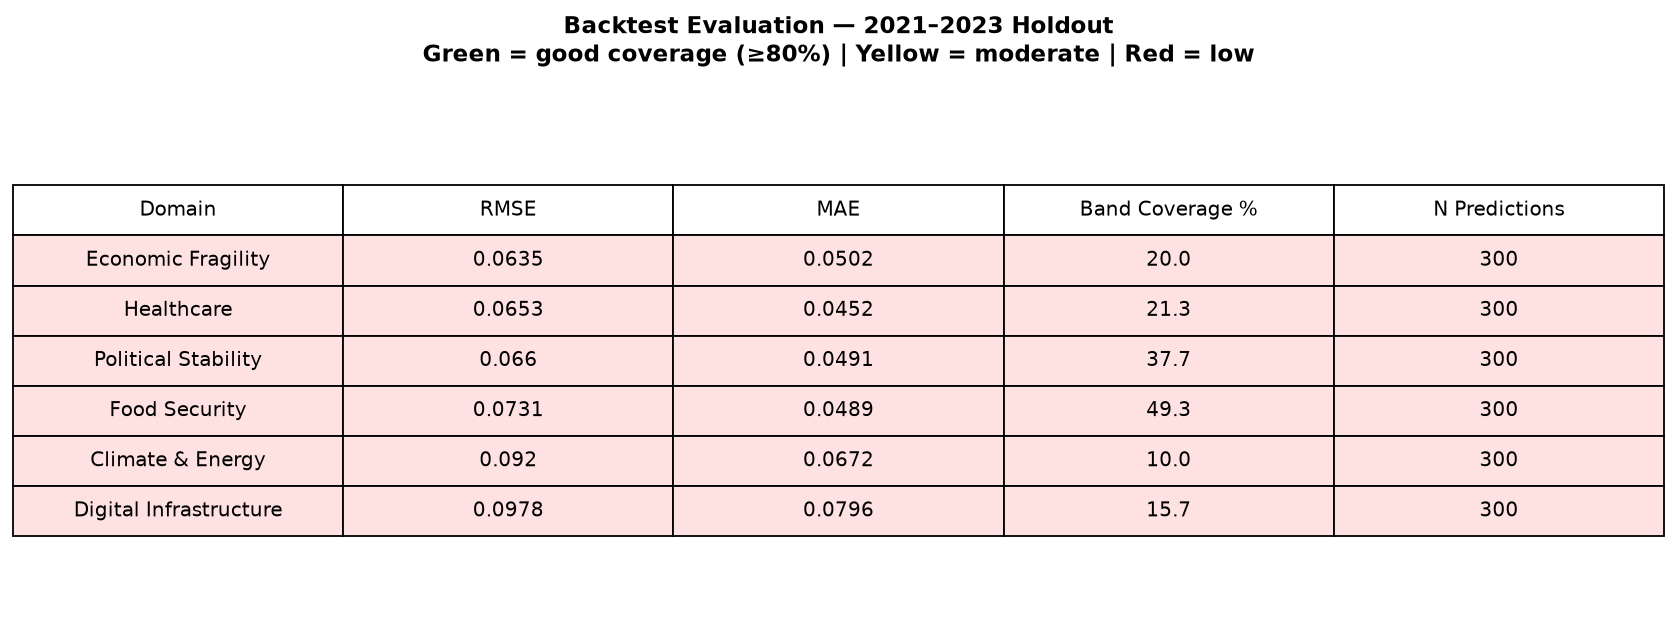

Saved: viz6_backtest_coverage.png

Full metrics table:
                Domain   RMSE    MAE  Coverage_%  N_Predictions
    Economic Fragility 0.0635 0.0502        20.0            300
            Healthcare 0.0653 0.0452        21.3            300
   Political Stability 0.0660 0.0491        37.7            300
         Food Security 0.0731 0.0489        49.3            300
      Climate & Energy 0.0920 0.0672        10.0            300
Digital Infrastructure 0.0978 0.0796        15.7            300


In [ ]:
# ==============================================================================
# VIZ : COVERAGE EVALUATION TABLE
# Shows backtest metrics per domain as a styled table visualization
# ==============================================================================

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')

display_metrics = metrics_df.rename(columns={
    'Domain':        'Domain',
    'RMSE':          'RMSE',
    'MAE':           'MAE',
    'Coverage_%':    'Band Coverage %',
    'N_Predictions': 'N Predictions',
}).round({'RMSE': 4, 'MAE': 4, 'Band Coverage %': 1})

col_labels = list(display_metrics.columns)
cell_text  = display_metrics.values.tolist()

# Color rows by coverage quality
cov_col_idx = display_metrics.columns.tolist().index('Band Coverage %')
row_colors = []
for row in cell_text:
    cov = float(row[cov_col_idx])
    if cov >= 80:
        color = '#d1fae5'   # green
    elif cov >= 60:
        color = '#fef3c7'   # yellow
    else:
        color = '#fee2e2'   # red
    row_colors.append([color] * len(col_labels))

tbl = ax.table(
    cellText=cell_text, colLabels=col_labels,
    cellColours=row_colors, loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.2)

ax.set_title(
    'Backtest Evaluation — 2021–2023 Holdout\n'
    'Green = good coverage (≥80%) | Yellow = moderate | Red = low',
    fontsize=13, fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz6_backtest_coverage.png'),
            bbox_inches='tight', dpi=130)
plt.show()
print("Saved: viz6_backtest_coverage.png")
print("\nFull metrics table:")
print(metrics_df.to_string(index=False))


<div style="
background:linear-gradient(135deg,#0F172A,#1E293B);
padding:18px 24px;
border-radius:18px;
color:#FBBF24;
font-size:26px;
font-weight:700;">

✨ 15. Final Output Summary

</div>

<sub style="color:#94A3B8;">
Summarize the final forecasts, rankings, and key outputs generated by the forecasting pipeline.
</sub>

In [21]:
# ==============================================================================
# FINAL SUMMARY — list all output files produced
# ==============================================================================

print("=" * 65)
print("   GLOBAL RESILIENCE INDEX — 2030 FORECAST COMPLETE")
print("=" * 65)

output_files = [
    ('domain_scores_2000_2023.csv',   'Domain scores for 100 in-filter countries, all years'),
    ('forecast_2030_scenarios.csv',   'Base/Opt/Pess forecasts per Country × Domain (in-filter)'),
    ('regression_params.csv',         'OLS parameters + backtest RMSE per Country × Domain'),
    ('backtest_results.csv',          'Predicted vs actual for 2021–2023 holdout'),
    ('out_of_filter_scores.csv',      'Estimated yearly domain scores for out-of-filter countries'),
    ('global_2030_ranking.csv',       'All countries ranked by 2030 Base Composite Score'),
    ('movers_2023_to_2030.csv',       'Biggest risers & fallers 2023 → 2030'),
    ('viz1_fan_charts.png',           'Fan charts: 10 countries with forecast bands'),
    ('viz2_bar_all_countries.png',    'Bar chart: all 100 countries with error bars'),
    ('viz3_top_bottom_15.png',        'Table: Top 15 and Bottom 15 countries in 2030'),
    ('viz4_biggest_movers.png',       'Biggest risers and fallers 2023 → 2030'),
    ('viz5_world_map.png',            'World map: 2030 Base composite score choropleth'),
    ('viz6_backtest_coverage.png',    'Backtest metrics + band coverage per domain'),
    ('viz7_domain_heatmap.png',       'Heatmap: Country × Domain scores for 2030'),
]

print(f"\n{'File':<45} {'Description'}")
print("-" * 90)
for fname, desc in output_files:
    full = os.path.join(OUTPUT_DIR, fname)
    exists = '✓' if os.path.exists(full) else '✗'
    print(f"  {exists}  {fname:<42} {desc}")

print("\n" + "=" * 65)
print("  BACKTEST SUMMARY")
print("=" * 65)
print(metrics_df[['Domain','RMSE','MAE','Coverage_%']].to_string(index=False))

print("\n" + "=" * 65)
print("  TOP 10 COUNTRIES — 2030 BASE COMPOSITE SCORE")
print("=" * 65)
print(
  
    composite
    .merge(country_in[['Country Code','Region']], on='Country Code')
    .rename(columns={'Region_x':'Region'})
    .sort_values('Composite_Base', ascending=False)
    .head(10)
    [['Country Name','Region','Composite_Base','Composite_Opt','Composite_Pess']]
)

print("\n" + "=" * 65)
print("  GLOBAL REACH")
print(f"  In-filter  countries in 2030 ranking : {(global_composite['Data_Type']=='Actual').sum()}")
print(f"  Estimated  countries in 2030 ranking : {(global_composite['Data_Type']=='Estimated').sum()}")
print(f"  Total countries in global ranking    : {len(global_composite)}")
print("=" * 65)


   GLOBAL RESILIENCE INDEX — 2030 FORECAST COMPLETE

File                                          Description
------------------------------------------------------------------------------------------
  ✓  domain_scores_2000_2023.csv                Domain scores for 100 in-filter countries, all years
  ✓  forecast_2030_scenarios.csv                Base/Opt/Pess forecasts per Country × Domain (in-filter)
  ✓  regression_params.csv                      OLS parameters + backtest RMSE per Country × Domain
  ✓  backtest_results.csv                       Predicted vs actual for 2021–2023 holdout
  ✓  out_of_filter_scores.csv                   Estimated yearly domain scores for out-of-filter countries
  ✓  global_2030_ranking.csv                    All countries ranked by 2030 Base Composite Score
  ✗  movers_2023_to_2030.csv                    Biggest risers & fallers 2023 → 2030
  ✗  viz1_fan_charts.png                        Fan charts: 10 countries with forecast bands
  ✗  viz2_bar_all_c